In [1]:
print("all ok")

all ok


### Config the model

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
model=ChatGoogleGenerativeAI(model='gemini-2.5-flash')
output=model.invoke("hi")
print(output.content)

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hi there! How can I help you today?


### Config the embedding model

In [2]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en")
len(embeddings.embed_query("hi"))

384

## lets take a data embedd it and store in VDB

In [3]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [4]:
loader=DirectoryLoader("./data2",glob="./*.txt",loader_cls=TextLoader)

In [5]:
docs=loader.load()

In [6]:
docs

[Document(metadata={'source': 'data2\\usa.txt'}, page_content="ðŸ‡ºðŸ‡¸ Overview of the U.S. Economy\nThe United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.\n\nU.S. GDP â€“ Size, Composition, and Global Share\nAs of 2024, the United Statesâ€™ nominal GDP is estimated to be around $28 trillion USD, accounting for approximately 25% of the global economy. It ranks #1 in the world by nominal GDP, far ahead of China (wh

In [7]:
docs[0].page_content

"ðŸ‡ºðŸ‡¸ Overview of the U.S. Economy\nThe United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.\n\nU.S. GDP â€“ Size, Composition, and Global Share\nAs of 2024, the United Statesâ€™ nominal GDP is estimated to be around $28 trillion USD, accounting for approximately 25% of the global economy. It ranks #1 in the world by nominal GDP, far ahead of China (which ranks 2nd). The U.S. GDP per capita is also among the high

In [8]:
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=50
)

In [9]:
new_docs=text_splitter.split_documents(documents=docs)

In [10]:
new_docs

[Document(metadata={'source': 'data2\\usa.txt'}, page_content='ðŸ‡ºðŸ‡¸ Overview of the U.S. Economy'),
 Document(metadata={'source': 'data2\\usa.txt'}, page_content='The United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy,'),
 Document(metadata={'source': 'data2\\usa.txt'}, page_content='It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a'),
 Document(metadata={'source': 'data2\\usa.txt'}, page_content='a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services.'),
 Document(metadata={'source': 'data2\\usa.txt'}, page_content='innovation, global trade, and financial

In [11]:
doc_string=[doc.page_content for doc in new_docs]

In [12]:
doc_string

['ðŸ‡ºðŸ‡¸ Overview of the U.S. Economy',
 'The United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy,',
 'It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a',
 'a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services.',
 'innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.',
 'U.S. GDP â€“ Size, Composition, and Global Share',
 'As of 2024, the United Statesâ€™ nominal GDP is estimated to be around $28 trillion USD, accounting for appr

In [13]:
len(doc_string)

56

In [14]:
db=Chroma.from_documents(new_docs,embeddings)

In [15]:
retriever=db.as_retriever(search_kwargs={"k": 3})

In [16]:
retriever.invoke("industrial growth of usa?")

[Document(metadata={'source': 'data2\\usa.txt'}, page_content='Looking forward, the U.S. economy is expected to grow at a moderate pace, powered by innovation in AI, green energy, robotics, biotech, and quantum computing. The Biden administrationâ€™s Inflation'),
 Document(metadata={'source': 'data2\\usa.txt'}, page_content='ðŸ‡ºðŸ‡¸ Overview of the U.S. Economy'),
 Document(metadata={'source': 'data2\\usa.txt'}, page_content='The U.S. economy remains the engine of global growth, backed by unmatched innovation, financial dominance, and a strong institutional framework. Its $28 trillion GDP and influence over global')]

## creation of pydantic class

In [17]:
import operator
from typing import List
from pydantic import BaseModel , Field
from langchain.prompts import PromptTemplate
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph,END

In [18]:
class TopicSelectionParser(BaseModel):
    Topic:str=Field(description="selected topic")
    Reasoning:str=Field(description='Reasoning behind topic selection')

In [19]:
from langchain.output_parsers import PydanticOutputParser

In [20]:
parser=PydanticOutputParser(pydantic_object=TopicSelectionParser)

In [21]:
parser.get_format_instructions()

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"Topic": {"description": "selected topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}\n```'

In [ ]:
'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"Topic": {"description": "selected topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}\n```'

### this below agentstate is just for the explnation like how state works

In [22]:
Agentstate={}

In [33]:
Agentstate["messages"]=[]
Agentstate["number"] = 0

In [ ]:
Agentstate["number"] += 1

In [35]:
Agentstate["number"]

1

In [ ]:
Agentstate

{'messages': []}

In [28]:
Agentstate["messages"]

[]

In [29]:
Agentstate["messages"].append("hi how are you?")

In [30]:
Agentstate

{'messages': ['hi how are you?']}

In [36]:
Agentstate["messages"].append("what are you doing?")

In [37]:
Agentstate

{'messages': ['what are you doing?'], 'number': 1}

In [38]:
Agentstate["messages"].append("i hope everything is fine")

In [39]:
Agentstate


{'messages': ['what are you doing?', 'i hope everything is fine'], 'number': 1}

In [40]:
Agentstate["messages"][-1]

'i hope everything is fine'

In [41]:
Agentstate["messages"][0]

'what are you doing?'

### this agentstate class you need to inside the stategraph

In [59]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [43]:
state={"messages":["hi"]}

In [44]:
state="hi"

In [45]:
def function_1(state:AgentState):
    
    question=state["messages"][-1]
    
    print("Question",question)
    
    template="""
    Your task is to classify the given user query into one of the following categories: [USA,Not Related]. 
    Only respond with the category name and nothing else.

    User query: {question}
    {format_instructions}
    """
    
    prompt= PromptTemplate(
        template=template,
        input_variable=["question"],
        partial_variables={"format_instructions": parser.get_format_instructions()}
    )
    
    
    chain= prompt | model | parser
    
    response = chain.invoke({"question":question})
    
    print("Parsed response:", response)
    
    return {"messages": [response.Topic]}

In [46]:
state={"messages":["what is a today weather?"]}

In [50]:
state={"messages":["what is a GDP of usa??"]}

In [51]:
state_resp = function_1(state)

Question what is a GDP of usa??
Parsed response: Topic='USA' Reasoning="The user query explicitly asks for the 'GDP of usa', which directly relates to the USA topic."


In [52]:
state_resp

{'messages': ['USA']}

In [50]:
class TopicSelectionParser(BaseModel):
    Topic:str=Field(description="selected topic")
    Reasoning:str=Field(description='Reasoning behind topic selection')

In [53]:
def router(state:AgentState):
    print("-> ROUTER ->")
    
    last_message=state["messages"][-1]
    print("last_message:", last_message)
    
    if "usa" in last_message.lower():
        return "RAG Call"
    else:
        return "LLM Call"

workflow.add_conditional_edges(
    "Supervisor",
    router,
    {
        "RAG Call": "RAG"(function_2),
        "LLM Call": "LLM"(function_3),
    }
)

In [54]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [55]:
# RAG Function
def function_2(state:AgentState):
    print("-> RAG Call ->")
    
    question = state["messages"][0]
    
    prompt=PromptTemplate(
        template="""You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:""",
        
        input_variables=['context', 'question']
    )
    
    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | model
        | StrOutputParser()
    )
    result = rag_chain.invoke(question)
    return  {"messages": [result]}

In [56]:
# LLM Function
def function_3(state:AgentState):
    print("-> LLM Call ->")
    question = state["messages"][0]
    
    # Normal LLM call
    complete_query = "Anwer the follow question with you knowledge of the real world. Following is the user question: " + question
    response = model.invoke(complete_query)
    return {"messages": [response.content]}

In [58]:
from langgraph.graph import StateGraph,END

In [60]:
workflow=StateGraph(AgentState)

In [61]:
workflow.add_node("Supervisor",function_1)

In [62]:
workflow.add_node("RAG",function_2)

In [63]:
workflow.add_node("LLM",function_3)

In [64]:
workflow.set_entry_point("Supervisor")

In [65]:
workflow.add_conditional_edges(
    "Supervisor",
    router,
    {
        "RAG Call": "RAG",
        "LLM Call": "LLM",
    }
)

In [66]:
workflow.add_edge("RAG",END)
workflow.add_edge("LLM",END)

In [67]:
app=workflow.compile()

In [69]:
state={"messages":["hi"]}

In [70]:
app.invoke(state)

Question hi
Parsed response: Topic='Not Related' Reasoning="The user query 'hi' is a generic greeting and does not contain any information or keywords related to 'USA'."
-> ROUTER ->
last_message: Not Related
-> LLM Call ->


{'messages': ['hi', 'Not Related', 'Hello! How can I help you today?']}

In [74]:
state={"messages":["what is a gdp of America?"]}

In [75]:
app.invoke(state)

Question what is a gdp of America?
Parsed response: Topic='USA' Reasoning="The user query explicitly asks about the 'gdp of America', and 'America' in this context refers to the United States of America, which directly falls under the 'USA' category."
-> ROUTER ->
last_message: USA
-> RAG Call ->


{'messages': ['what is a gdp of America?',
  'USA',
  "As of 2024, the United States' nominal GDP is estimated to be around $28 trillion USD. This accounts for approximately 25% of the global economy. The U.S. ranks #1 in the world by nominal GDP."]}

In [76]:
state={"messages":["can you tell me the industrial growth of world's most powerful economy?"]}

In [69]:
state={"messages":["can you tell me the industrial growth of world's poor economy?"]}

In [77]:
result=app.invoke(state)

Question can you tell me the industrial growth of world's most powerful economy?
Parsed response: Topic='USA' Reasoning="The 'world's most powerful economy' is widely recognized as referring to the United States."
-> ROUTER ->
last_message: USA
-> RAG Call ->


In [78]:
result

{'messages': ["can you tell me the industrial growth of world's most powerful economy?",
  'USA',
  "The provided context identifies the United States as the world's most powerful economy. However, it does not contain information regarding its industrial growth. The context focuses on its nominal GDP, economic structure, and its role as an engine of global growth."]}

In [79]:
result["messages"][-1]

"The provided context identifies the United States as the world's most powerful economy. However, it does not contain information regarding its industrial growth. The context focuses on its nominal GDP, economic structure, and its role as an engine of global growth."

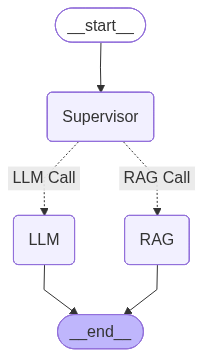

In [80]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
Assignment:1
1. you have to create one supervisor node.
2. create one router function
3. create three more node
3.1 llm call (llm node)
3.2 RAG (rag node)
3.3 web crawler(fetch the info in realtime from internet)
4. created one more node after this for validation for generated output --> explore the validation part how to do that
5. if validation going to be failed in that case again go to supervioser node and then supervisor node will again decide what needs to be call next
6. once the validation will pass then only generate the final output

submission deadline till 9pm friday

submission instruction:
create your github repo and keep all the assisgnments over there(in that github repo)
i will share one googleform in group after completing your assignment you can share the github link through that google form. 

in next class will discuss about the 
1. react agent with multiple tool call
2.  agentic rag